# Práctica III: Aerolíneas y Satisfacción

Elena & Carlos Garrido del Toro

Inteligencia Artificial a 14 de Enero de 2026

---

## 1. Introducción y Objetivos

El objetivo principal de este ejercicio es aplicar conceptos y técnicas de **Aprendizaje Automático Supervisado** .Trabajaremos con el conjunto de datos *Airline Passenger Satisfaction Dataset*, el cual contiene información demográfica de pasajeros, detalles de sus vuelos y puntuaciones sobre servicios específicos (wifi, comida, comodidad, etc.).

El objetivo es predecir la variable `satisfaction` (si un pasajero está "Satisfecho" o "Neutral/Insatisfecho"). Para ello, compararemos el rendimiento de los siguientes modelos:

1.  Perceptrón
2.  Regresión Logística
3.  Máquinas de Vectores de Soporte (SVM)
4.  Árboles de Decisión
5.  Bosques Aleatorios (Random Forest)

In [41]:
# Importación de librerías fundamentales requeridas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mostrar gráficos integrados
%matplotlib inline

# Importación de herramientas de preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Importación de librerías para clustering
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


print("Entorno configurado correctamente. Listo para cargar datos.")

Entorno configurado correctamente. Listo para cargar datos.


Importamos el DataSet descargado y ubicado en la carpeta del proyecto

In [42]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_csv("airline_passenger_satisfaction.csv")

## 2. Preprocesamiento

Para poder tratar los datos con nuestros modelos de aprendizaje debemos de normalizar los datos, tratar las variables categóricas y tratar las variables nulas (NaNs)

### 2.1 Selecció de característiques (Feature Selection)

In [43]:
# Muestra las primeras filas para ver la estructura
print(f"Dimensions del dataset: {df.shape}")
display(df.head())

Dimensions del dataset: (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,satisfied


Nuestros datos contienen 25976 filas y 25 columnas de las cuales debemos eliminar las dos primera columnas `Unnamed` e `id` que no aportan información útil para la predicción.

In [44]:
# Eliminalos las columans que no son necesarias
cols_to_drop = ['Unnamed: 0', 'id']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Miramos las columnas restantes
print(df.columns.tolist())

['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


### 2.2 Limpieza y Transformación de Datos

#### Gestión de Valores Nulos (NaNs)

Los valores perdidos o nulos (NaNs) en un conjunto de datos pueden impedir el correcto funcionamiento de los algoritmos, ya que estos no pueden operar sobre datos inexistentes. Por ello, es imprescindible tratarlos antes de iniciar el entrenamiento.

Existen diversas técnicas para resolver este problema:
1.  **Eliminar filas:** Descartar los registros que contengan algún valor nulo.
2.  **Eliminar columnas:** Descartar la variable completa si tiene demasiados ausentes.
3.  **Imputación por valor fijo:** Sustituir el nulo por una constante.
4.  **Imputación estadística:** Sustituir el nulo por una medida de tendencia central, como la **media** o la mediana.

Nos hemos decantado por usar una estrategia híbrida:
* Para las **variables numéricas** (como *Arrival Delay*), sustituimos los valores faltantes con la **media** de la columna. Esto nos permite conservar la fila y no perder información valiosa del resto de características del pasajero.
* Para la **variable objetivo** (`satisfaction`), eliminaremos las filas que no tengan este dato. Al ser la etiqueta que queremos predecir (nuestra "verdad"), inventar este dato introduciría ruido y falsedades en el entrenamiento supervisado.

In [45]:
# 1. Eliminamos las filas donde no tenemos la variable objetivo 'satisfaction'
df.dropna(subset=['satisfaction'], inplace=True)

# 2. Para el resto de columnas numéricas, rellenamos con la media (Imputación)
# Seleccionamos solo columnas numéricas para evitar errores con las de texto
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Verificamos que ya no queden nulos
print(f"Nulos restantes: {df.isna().sum().sum()}")

Nulos restantes: 0


#### Conversión de Numeros 
Ahora procedemos a convertir las variables de texto en números para que los modelos de aprendizaje puedan trabajar con ellos.
1. `Gender` (Male/Female).
2. `Customer Type` (Loyal/Disloyal).
3. `Type of Travel` (Business / Personal).
4. `Class` (Business / Eco / Eco Plus).
5. `Satisfaction` (satisfied / neutral or dissatisfied) -> Variable Objetivo

In [46]:

# Lista de columnas categóricas (texto) en el dataset de Aerolíneas
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

# Creamos el codificador
le = LabelEncoder()

# Aplicamos la transformación a cada columna
for col in categorical_cols:
    # Ajustamos y transformamos la columna
    df[col] = le.fit_transform(df[col])
    
    # Imprimimos qué número se ha asignado a cada texto para tenerlo de referencia
    print(f"Codificación para '{col}':")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")
    print("\n")

print("\nDataset transformado a numérico")
display(df.head())

Codificación para 'Gender':
  Female -> 0
  Male -> 1


Codificación para 'Customer Type':
  Loyal Customer -> 0
  disloyal Customer -> 1


Codificación para 'Type of Travel':
  Business travel -> 0
  Personal Travel -> 1


Codificación para 'Class':
  Business -> 0
  Eco -> 1
  Eco Plus -> 2


Codificación para 'satisfaction':
  neutral or dissatisfied -> 0
  satisfied -> 1



Dataset transformado a numérico


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,1,160,5,4,3,4,3,4,3,5,5,5,5,2,5,5,50,44.0,1
1,0,0,36,0,0,2863,1,1,3,1,5,4,5,4,4,4,4,3,4,5,0,0.0,1
2,1,1,20,0,1,192,2,0,2,4,2,2,2,2,4,1,3,2,2,2,0,0.0,0
3,1,0,44,0,0,3377,0,0,0,2,3,4,4,1,1,1,1,3,1,4,0,6.0,1
4,0,0,49,0,1,1182,2,3,4,3,4,1,2,2,2,2,2,4,2,4,0,20.0,1


#### Normalización de Datos

Finalmente, para completar el preprocesamiento del dataset, es indispensable **normalizar los datos**. Actualmente, tenemos variables con escalas muy diferentes; por ejemplo, `Flight Distance` tiene valores en los miles (ej: 3000 km), mientras que `Age` o las puntuaciones de encuestas se mueven en rangos mucho menores (0-5 o 0-100).

Esta diferencia en las escalas es problematica, ya que, hace que los algoritmos basados en distancias (como **SVM** o **K-Means**) fallen o den más importancia errónea a las variables con números más grandes. Además, provoca que el entrenamiento de modelos como la **Regresión Logística** o el **Perceptrón** sea mucho más lento al dificultar la convergencia.

Para solucionar esto, aplicaremos `StandardScaler` (Estandarización), transformando las variables para que tengan una media de 0 y una desviación estándar de 1.

In [47]:

# No queremos normalizar 'satisfaction', es el objetivo
target = 'satisfaction'
X = df.drop(target, axis=1)
y = df[target]

# Inicializamos el escalador
scaler = StandardScaler()

# Ajustamos y transformamos los datos
# Devuelve un array de numpy, así que lo volvemos a convertir a DataFrame para no perder los nombres de columnas
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(" Datos Normalizados (Primeras filas)")
display(X_scaled.head())

# Descripción para ver que la media es 0 y la desviación estándar es 1
print("\nEstadísticas tras la normalización")
display(X_scaled.describe().round(2))

 Datos Normalizados (Primeras filas)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,-0.985932,-0.476040,0.817887,-0.663378,0.652923,-1.035171,1.703853,0.621641,0.172143,0.797831,-0.161739,0.544692,-0.340303,1.227138,1.259170,1.250974,1.161716,-1.035348,1.144063,1.298998,0.953810,0.781143
1,-0.985932,-0.476040,-0.239238,-0.663378,-0.950436,1.671443,-1.291598,-1.334871,0.172143,-1.542065,1.340348,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,-0.247517,0.297077,1.298998,-0.382286,-0.393543
2,1.014269,2.100665,-1.296363,-0.663378,0.652923,-1.003128,-0.542735,-1.987042,-0.535609,0.797831,-0.912783,-0.930768,-1.097842,-1.014556,0.479178,-1.782001,-0.538238,-1.035348,-1.396893,-0.974927,-0.382286,-0.393543
3,1.014269,-0.476040,0.289325,-0.663378,-0.950436,2.186131,-2.040460,-1.987042,-1.951114,-0.762100,-0.161739,0.544692,0.417235,-1.761787,-1.860800,-1.782001,-2.238193,-0.247517,-2.243878,0.541023,-0.382286,-0.233358
4,-0.985932,-0.476040,0.619676,-0.663378,0.652923,-0.011804,-0.542735,-0.030530,0.879895,0.017866,0.589304,-1.668498,-1.097842,-1.014556,-1.080807,-1.023758,-1.388216,0.540315,-1.396893,0.541023,-0.382286,0.140405



Estadísticas tras la normalización


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00,25976.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.99,-0.48,-2.16,-0.66,-0.95,-1.16,-2.04,-1.99,-1.95,-1.54,-2.41,-2.41,-1.86,-2.51,-2.64,-2.54,-2.24,-1.82,-3.09,-2.49,-0.38,-0.39
25%,-0.99,-0.48,-0.83,-0.66,-0.95,-0.78,-0.54,-0.68,-0.54,-0.76,-0.91,-0.93,-1.10,-1.01,-1.08,-1.02,-0.54,-0.25,-0.55,-0.97,-0.38,-0.39
50%,-0.99,-0.48,0.03,-0.66,0.65,-0.35,0.21,-0.03,0.17,0.02,-0.16,0.54,0.42,0.48,0.48,0.49,0.31,-0.25,0.30,-0.22,-0.38,-0.39
75%,1.01,-0.48,0.75,1.51,0.65,0.55,0.95,0.62,0.88,0.80,0.59,0.54,1.17,0.48,0.48,0.49,1.16,0.54,1.14,0.54,-0.06,-0.05
max,1.01,2.10,3.00,1.51,2.26,3.79,1.70,1.27,1.59,1.58,1.34,1.28,1.17,1.23,1.26,1.25,1.16,1.33,1.14,1.30,29.76,29.37


## 3. Análisis Exploratorio de Datos (EDA)

El siguiente paso consiste en agrupar a los pasajeros automáticamente mediante técnicas de aprendizaje no supervisado. El objetivo es descubrir si existen perfiles de usuarios diferenciados (por ejemplo, 'Viajeros de negocios exigentes' frente a 'Turistas relajados') antes de abordar la predicción supervisada.

Realizamos esto para comprender mejor la estructura de los datos y detectar qué características (edad, clase, distancia) definen realmente el comportamiento de los pasajeros.

Antes de ejecutar el algoritmo K-Means, debemos determinar qué número de grupos ($k$) es el más eficiente. Para ello, nos apoyaremos en el Método del Codo (Elbow Method), una técnica que nos permite visualizar gráficamente el punto de inflexión donde se optimiza la relación entre el número de clústeres y la cohesión de los mismos. [Fuente del método](https://jarroba.com/seleccion-del-numero-optimo-clusters/#google_vignette)

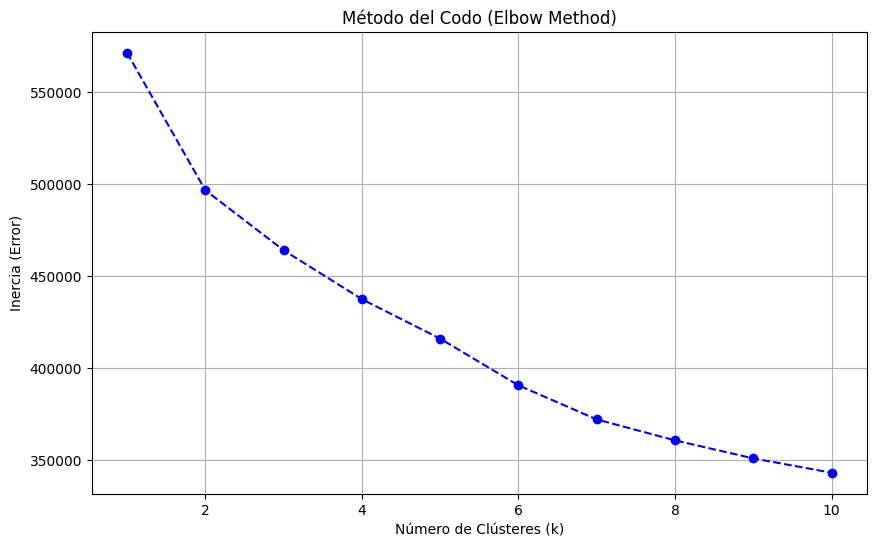

In [48]:
# Definimos un rango de 1 a 10 posibles grupos (clusters)
inertia = []
K_range = range(1, 11)

# Probamos K-Means con diferentes cantidades de grupos
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)  # Usamos los datos normalizados 
    inertia.append(kmeans.inertia_)

# Dibujamos la Gráfica del Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia (Error)')
plt.grid(True)
plt.show()

Analizando la gráfica, observamos que el primer punto de inflexión (codo) se encuentra en $k=2$. Sin embargo, dado que en $k=3$ la pendiente sigue mostrando una mejora similar, nos decantamos por escoger $k=3$. Esto nos permitirá obtener una mayor granularidad en el análisis, detectando matices en los perfiles de pasajeros que una división binaria podría pasar por alto.

In [49]:
# APLICAR EL CLUSTERING (K=3)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# GUARDAR LOS RESULTADOS
# Creamos una copia del dataset ORIGINAL
df_analisis = df.copy()
df_analisis['Cluster'] = clusters  # Añadimos la columna con el grupo (0, 1 o 2)

# Agrupamos por clúster y sacamos la media de alguna de las variables más importantes
perfil_grupos = df_analisis.groupby('Cluster')[['Age', 'Flight Distance', 'Class', 'Type of Travel', 'satisfaction', 'Inflight wifi service']].mean().round(2)

print("--- CARACTERÍSTICAS QUE DEFINEN CADA GRUPO ---")
display(perfil_grupos)

# Ver cuánta gente hay en cada grupo
print("\n--- Cantidad de pasajeros por grupo ---")
print(df_analisis['Cluster'].value_counts())

--- CARACTERÍSTICAS QUE DEFINEN CADA GRUPO ---


,Age,Flight Distance,Class,Type of Travel,satisfaction,Inflight wifi service
Cluster,,,,,,
0,33.12,838.52,0.88,0.47,0.17,2.35
1,41.93,1043.03,0.76,0.35,0.26,2.53
2,42.13,1538.23,0.28,0.16,0.75,3.12



--- Cantidad de pasajeros por grupo ---
Cluster
2    10822
1     8098
0     7056
Name: count, dtype: int64


## 4.Preparacion para Modelos Supervisados
Ahora procederemos a dividir nuestros datos en dos conjuntos distintos, uno de entrenamiento y otro de prueba. Esta division es importante para poder evaluar nuestros modelos de manera adecuada. 

Hemos considereado dividir los datos de la siguiente manera un (70% ) para entrenamiento y un (30%) para las pruebas, asi podremos evaluar el rendimiento con datos que nunca haya visto.

Usamos train_test_split con: test_size= 0.3 (para los de prueba ) y importante destacar el stratify =y que nos mantiene la proporcion de clases para los dos conjuntos 


In [50]:

# Dividimos los datos en entrenamiento (70%) y prueba (30%)
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}")
print(f"\nDistribución de clases en entrenamiento:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribución de clases en prueba:\n{y_test.value_counts(normalize=True)}")

Dimensiones del conjunto de entrenamiento: (18183, 22)
Dimensiones del conjunto de prueba: (7793, 22)

Distribución de clases en entrenamiento:
satisfaction
0    0.561019
1    0.438981
Name: proportion, dtype: float64

Distribución de clases en prueba:
satisfaction
0    0.561016
1    0.438984
Name: proportion, dtype: float64


## 4.2 Definición de Métricas de Evaluacion 
para comparar los diferentes modelos necesitamos diferentes metricas para observar distintos aspectos de su rendimiento. 

Metricas Implementadas: 

1. Accuaracy(Precisión).

2. Matriz de Confusión.

3. Precision.

4. Recall(Sensibilidad).

5. F1-Score.

In [51]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre_modelo):
    """
    Función para evaluar cualquier modelo de clasificación
    """
    # Entrenar el modelo
    modelo.fit(X_train, y_train)
    
    # Predecir en entrenamiento y prueba
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    # Calcular métricas
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Reporte de clasificación
    report = classification_report(y_test, y_test_pred, output_dict=True)
    
    # Calcular precision, recall y f1
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    # Calcular AUC-ROC (si el modelo tiene predict_proba)
    try:
        y_test_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_test_proba)
    except:
        auc = None
    
    # Resultados
    resultados = {
        'Modelo': nombre_modelo,
        'Accuracy Train': accuracy_train,
        'Accuracy Test': accuracy_test,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Confusion Matrix': cm,
        'Classification Report': report
    }
    
    return resultados

def mostrar_resultados(resultados, modelo, X_test, y_test):
    """
    Función para mostrar los resultados de forma ordenada
    """
    print(f"=== RESULTADOS: {resultados['Modelo']} ===")
    print(f"Accuracy (Train): {resultados['Accuracy Train']:.4f}")
    print(f"Accuracy (Test): {resultados['Accuracy Test']:.4f}")
    print(f"Precision: {resultados['Precision']:.4f}")
    print(f"Recall: {resultados['Recall']:.4f}")
    print(f"F1-Score: {resultados['F1-Score']:.4f}")
    if resultados['AUC-ROC'] is not None:
        print(f"AUC-ROC: {resultados['AUC-ROC']:.4f}")
    
    print("\nMatriz de Confusión:")
    print(resultados['Confusion Matrix'])
    
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, modelo.predict(X_test)))
    
    return resultados

## 5. Entrenamiento de los modelos.
### 5.1. Perceptron.

Para el Perceptron hemos decidido escoger estos hiperparametros y implementarlos para descubrir cual es el que mejor resulatdos nos da, teniendo en cuenta que si cubrimos demasiado poco puede ser inestable y si cubrimos demasiado puede ser demasiado lento. 

Tenemos para `max_iter` 100, 500 y 1000, hemos codigo 1000 por si a caso nuestro dataser es complejo y necesita mas convergencia.

Por otra parte tenemos `eta0` con 0.1, 0.01, 0.001  estos nos determinan la tasa de aprendizaje inicial.

#### Estrategia de Validacion

Hemos implementado un `5-fold-cross-validation` esto significa que del 70 % que le hemos dado de los datos para entrenar, lo divide en 5 secciones, entrena 4 folds y valida 1 fold, repitiendolo 5 veces. Esto nos ayuda a ajustar los hiperparametros, eviatr sobreajustes y mejoramos la estiamacion del rendimiento

¿Cómo consideramos cuales son los mejores hiperparametros?
La metrica de evaluacion es `accuracy` (precision ), consideramos que precision seria una buena metrica ya que tenemos unas clases balanceadas, pudiendonos dar asi precision unos datos relevantes para poder comoparar los diferentes modelos de la combinacion de hiperparametros.



In [52]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import GridSearchCV

# Definir el modelo base
perceptron = Perceptron(random_state=42)

# Definir la grilla de hiperparámetros
param_grid_perceptron = {
    'max_iter': [100, 500, 1000],
    'eta0': [0.1, 0.01, 0.001]
}

# Búsqueda de mejores hiperparámetros con validación cruzada
grid_perceptron = GridSearchCV(
    perceptron, 
    param_grid_perceptron, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Métrica de evaluación
    n_jobs=-1,  # Usar todos los núcleos disponibles
    verbose=1
)

# Entrenar con búsqueda de hiperparámetros
grid_perceptron.fit(X_train, y_train)

print(f"Mejores hiperparámetros para Perceptrón: {grid_perceptron.best_params_}")
print(f"Mejor score en validación cruzada: {grid_perceptron.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores hiperparámetros para Perceptrón: {'eta0': 0.1, 'max_iter': 100}
Mejor score en validación cruzada: 0.7904


Ahora lo que hacemos es coger los mejores hiperparametros que hemos conseguido y evaluamos el modelo con los datos de prueba intactos el 30 % 

In [53]:
# Usar el mejor modelo encontrado
best_perceptron = grid_perceptron.best_estimator_

# Evaluar el modelo
resultados_perceptron = evaluar_modelo(best_perceptron, X_train, X_test, y_train, y_test, "Perceptrón")
mostrar_resultados(resultados_perceptron, best_perceptron, X_test, y_test)

=== RESULTADOS: Perceptrón ===
Accuracy (Train): 0.8297
Accuracy (Test): 0.8260
Precision: 0.8141
Recall: 0.7822
F1-Score: 0.7979

Matriz de Confusión:
[[3761  611]
 [ 745 2676]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      4372
           1       0.81      0.78      0.80      3421

    accuracy                           0.83      7793
   macro avg       0.82      0.82      0.82      7793
weighted avg       0.83      0.83      0.83      7793



{'Modelo': 'Perceptrón',
 'Accuracy Train': 0.8296760710553814,
 'Accuracy Test': 0.8259976902348262,
 'Precision': 0.8141162153939763,
 'Recall': 0.7822274188833674,
 'F1-Score': 0.7978533094812165,
 'AUC-ROC': None,
 'Confusion Matrix': array([[3761,  611],
        [ 745, 2676]]),
 'Classification Report': {'0': {'precision': 0.834664891256103,
   'recall': 0.8602470265324794,
   'f1-score': 0.8472628970488849,
   'support': 4372.0},
  '1': {'precision': 0.8141162153939763,
   'recall': 0.7822274188833674,
   'f1-score': 0.7978533094812165,
   'support': 3421.0},
  'accuracy': 0.8259976902348262,
  'macro avg': {'precision': 0.8243905533250396,
   'recall': 0.8212372227079234,
   'f1-score': 0.8225581032650506,
   'support': 7793.0},
  'weighted avg': {'precision': 0.8256443574277526,
   'recall': 0.8259976902348262,
   'f1-score': 0.8255728933187433,
   'support': 7793.0}}}

Visualizamos el efecto de los hiperparametros

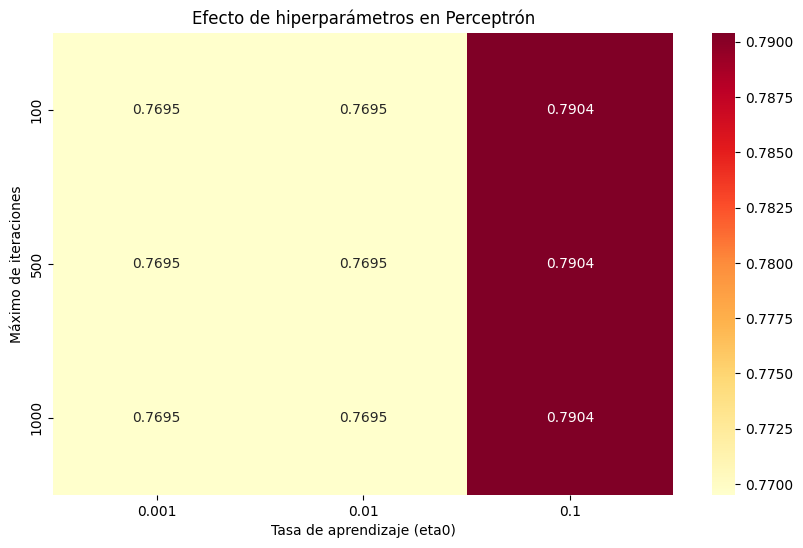

In [54]:
# Análisis de resultados de GridSearchCV
import pandas as pd

# Convertir resultados a DataFrame
cv_results = pd.DataFrame(grid_perceptron.cv_results_)

# Filtrar columnas relevantes
cv_results_filtered = cv_results[['param_max_iter', 'param_eta0', 'mean_test_score', 'std_test_score']]

# Crear pivot table para visualización
pivot_table = cv_results_filtered.pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_eta0'
)

# Visualizar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd')
plt.title('Efecto de hiperparámetros en Perceptrón')
plt.xlabel('Tasa de aprendizaje (eta0)')
plt.ylabel('Máximo de iteraciones')
plt.show()

In [55]:
# Tabla resumen de métricas
import pandas as pd

metricas_perceptron = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Entrenamiento': [0.8297, 'N/A', 'N/A', 'N/A'],
    'Prueba': [0.8260, 0.8141, 0.7822, 0.7979]
})

print("Resumen de métricas del Perceptrón:")
print(metricas_perceptron)

Resumen de métricas del Perceptrón:
     Métrica Entrenamiento  Prueba
0   Accuracy        0.8297  0.8260
1  Precision           N/A  0.8141
2     Recall           N/A  0.7822
3   F1-Score           N/A  0.7979


### Evaluacion del Perceptron 

A primera vista lo mas destacable es que da diferencia de Accuraacy entre el Entrenamiento y la Prueba es muy pequeña, esto es una buena señal de que el modelo no esta sobreajustado y generaliza bien a datos nuevos.

Tambien observamos un **F1-Score** del 79.79 % que nos indica un equilibrio entre precision y recall.

##### Errores que ha tenido el modelo 
El modelo ha detectado 611 casos de **Falsos Positivos**, es decir hemos tenido 611 pasajeros instatisfechos clasificados como satisfechos. 

Por otra parte hemos tenido 745 casos de **Falsos Negativos** pasajeros que si estaban satisfechos han sido classificados cono insatisfechos.



## 5.2 Regresion Logistica 